<a href="https://colab.research.google.com/github/eli576/Other/blob/main/Shark_count_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving Shark Count 2025 database.xlsx to Shark Count 2025 database.xlsx


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
data = pd.read_excel('Shark Count 2025 database.xlsx')
data.head()

,reportType,region,island,diveSite,uid,date,isHistoric,Hammerhead shark,Galapagos shark,Galapagos bullhead shark,...,Shortfin sunfish,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,Scuba dive,Galapagos Islands,Baltra,Mosquera,Sw1ozlnw9JcHk02mFtbps8Fc8OK2,2025-09-02T16:00:00.000Z,NaN,5.0,8.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Scuba dive,Galapagos Islands,Wolf,Shark Bay,2uyOIFEMpkOKDLp9YIWgdGrw0WA2,2025-08-29T21:30:00.000Z,NaN,30.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Scuba dive,Galapagos Islands,Wolf,Rockfall,2uyOIFEMpkOKDLp9YIWgdGrw0WA2,2025-08-29T19:30:00.000Z,NaN,15.0,34.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Scuba dive,Galapagos Islands,Wolf,Rockfall,2uyOIFEMpkOKDLp9YIWgdGrw0WA2,2025-08-29T16:30:00.000Z,NaN,11.0,38.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Scuba dive,Galapagos Islands,Wolf,Shark Bay,2uyOIFEMpkOKDLp9YIWgdGrw0WA2,2025-08-29T13:30:00.000Z,NaN,24.0,5.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
# Find the index of the 'images' column
images_col_idx = data.columns.get_loc('Shortfin sunfish')

data_cleaned = data.iloc[:, :images_col_idx +1]
print("Columns after 'images' have been deleted.")
display(data_cleaned.head())

Columns after 'images' have been deleted.


,reportType,region,island,diveSite,uid,date,isHistoric,Hammerhead shark,Galapagos shark,Galapagos bullhead shark,...,Whitetip reef shark,Silvertip shark,Whale shark,Green turtle,Hawksbill turtle,Giant manta,Golden cownose ray,Spotted eagle ray,Devil ray,Shortfin sunfish
0,Scuba dive,Galapagos Islands,Baltra,Mosquera,Sw1ozlnw9JcHk02mFtbps8Fc8OK2,2025-09-02T16:00:00.000Z,NaN,5.0,8.0,NaN,...,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN
1,Scuba dive,Galapagos Islands,Wolf,Shark Bay,2uyOIFEMpkOKDLp9YIWgdGrw0WA2,2025-08-29T21:30:00.000Z,NaN,30.0,2.0,NaN,...,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN
2,Scuba dive,Galapagos Islands,Wolf,Rockfall,2uyOIFEMpkOKDLp9YIWgdGrw0WA2,2025-08-29T19:30:00.000Z,NaN,15.0,34.0,NaN,...,NaN,NaN,NaN,8.0,NaN,NaN,NaN,7.0,NaN,NaN
3,Scuba dive,Galapagos Islands,Wolf,Rockfall,2uyOIFEMpkOKDLp9YIWgdGrw0WA2,2025-08-29T16:30:00.000Z,NaN,11.0,38.0,NaN,...,NaN,NaN,NaN,6.0,NaN,NaN,NaN,5.0,NaN,NaN
4,Scuba dive,Galapagos Islands,Wolf,Shark Bay,2uyOIFEMpkOKDLp9YIWgdGrw0WA2,2025-08-29T13:30:00.000Z,NaN,24.0,5.0,NaN,...,NaN,NaN,NaN,7.0,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
# Identify the animal count columns (starting from index 11 as per previous analysis)
animal_cols = data_cleaned.columns[11:data_cleaned.columns.get_loc('Shortfin sunfish') + 1]

# Backfill NaN values in these columns with 0
data_cleaned[animal_cols] = data_cleaned[animal_cols].fillna(0)

print("NaN values in animal count columns have been backfilled with 0.")
display(data_cleaned.head())

NaN values in animal count columns have been backfilled with 0.


,reportType,region,island,diveSite,uid,date,isHistoric,Hammerhead shark,Galapagos shark,Galapagos bullhead shark,...,Whitetip reef shark,Silvertip shark,Whale shark,Green turtle,Hawksbill turtle,Giant manta,Golden cownose ray,Spotted eagle ray,Devil ray,Shortfin sunfish
0,Scuba dive,Galapagos Islands,Baltra,Mosquera,Sw1ozlnw9JcHk02mFtbps8Fc8OK2,2025-09-02T16:00:00.000Z,NaN,5.0,8.0,NaN,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Scuba dive,Galapagos Islands,Wolf,Shark Bay,2uyOIFEMpkOKDLp9YIWgdGrw0WA2,2025-08-29T21:30:00.000Z,NaN,30.0,2.0,NaN,...,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Scuba dive,Galapagos Islands,Wolf,Rockfall,2uyOIFEMpkOKDLp9YIWgdGrw0WA2,2025-08-29T19:30:00.000Z,NaN,15.0,34.0,NaN,...,0.0,0.0,0.0,8.0,0.0,0.0,0.0,7.0,0.0,0.0
3,Scuba dive,Galapagos Islands,Wolf,Rockfall,2uyOIFEMpkOKDLp9YIWgdGrw0WA2,2025-08-29T16:30:00.000Z,NaN,11.0,38.0,NaN,...,0.0,0.0,0.0,6.0,0.0,0.0,0.0,5.0,0.0,0.0
4,Scuba dive,Galapagos Islands,Wolf,Shark Bay,2uyOIFEMpkOKDLp9YIWgdGrw0WA2,2025-08-29T13:30:00.000Z,NaN,24.0,5.0,NaN,...,0.0,0.0,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
data_cleaned.columns.unique()


Index(['reportType', 'region', 'island', 'diveSite', 'uid', 'date',
       'isHistoric', 'Hammerhead shark', 'Galapagos shark',
       'Galapagos bullhead shark', 'Silky shark', 'Tiger shark',
       'Blacktip shark', 'Whitetip reef shark', 'Silvertip shark',
       'Whale shark', 'Green turtle', 'Hawksbill turtle', 'Giant manta',
       'Golden cownose ray', 'Spotted eagle ray', 'Devil ray',
       'Shortfin sunfish'],
      dtype='object')

In [ ]:
#convert date to date time
#all individual dive sites - diveSite.unique
#import the dive site info from padi into the map
#all column names

#abundance of sea turtles over time

#hotspot for sunfish

#compare


In [10]:
print(data_cleaned.columns[7:])

Index(['Hammerhead shark', 'Galapagos shark', 'Galapagos bullhead shark',
       'Silky shark', 'Tiger shark', 'Blacktip shark', 'Whitetip reef shark',
       'Silvertip shark', 'Whale shark', 'Green turtle', 'Hawksbill turtle',
       'Giant manta', 'Golden cownose ray', 'Spotted eagle ray', 'Devil ray',
       'Shortfin sunfish'],
      dtype='object')


/tmp/ipykernel_5991/2203117226.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='diveSite', y=col, data=animal_per_site, palette='viridis')


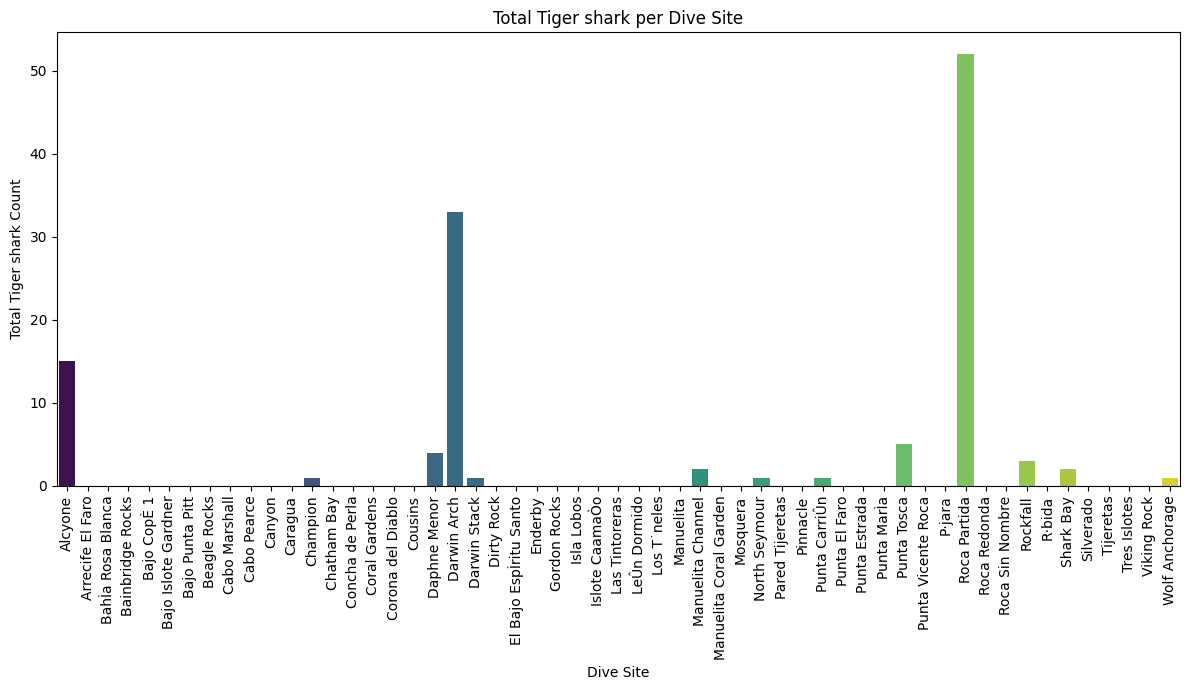

/tmp/ipykernel_5991/2203117226.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='diveSite', y=col, data=animal_per_site, palette='viridis')


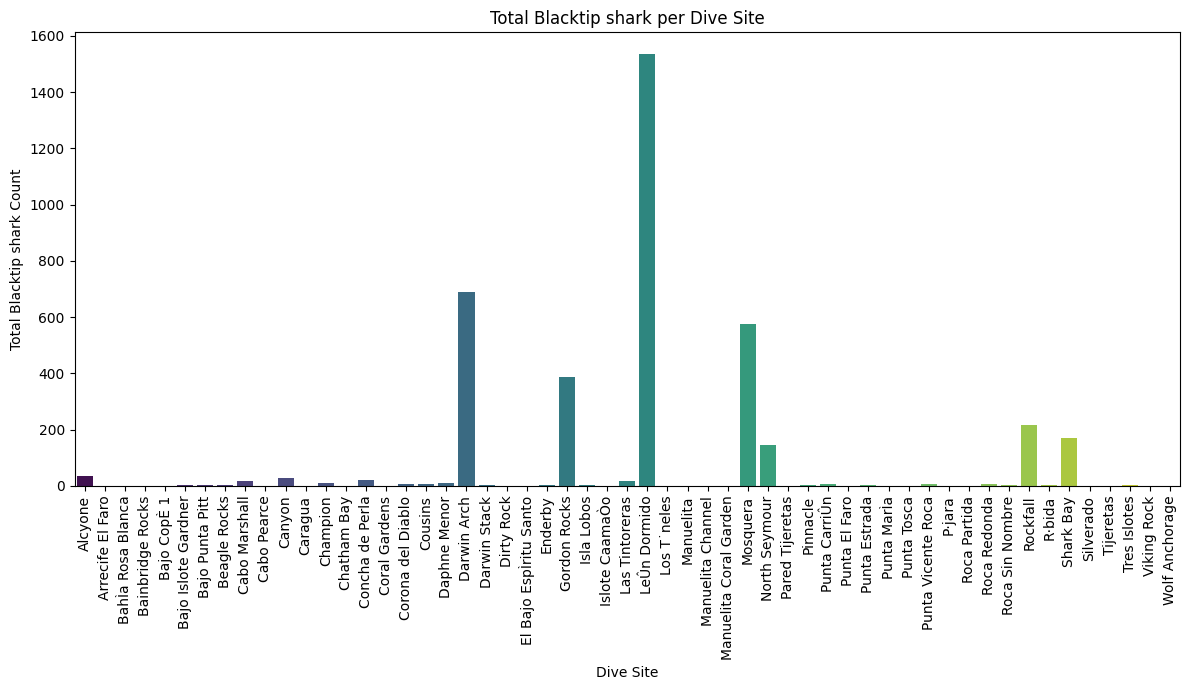

/tmp/ipykernel_5991/2203117226.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='diveSite', y=col, data=animal_per_site, palette='viridis')


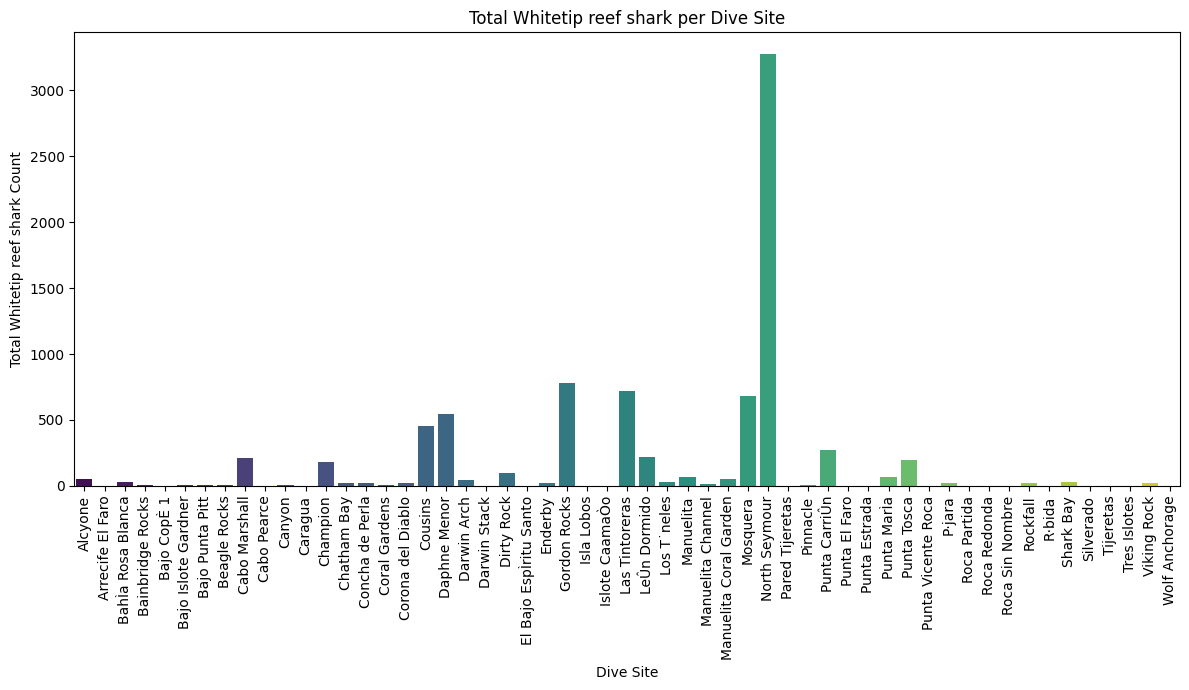

/tmp/ipykernel_5991/2203117226.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='diveSite', y=col, data=animal_per_site, palette='viridis')


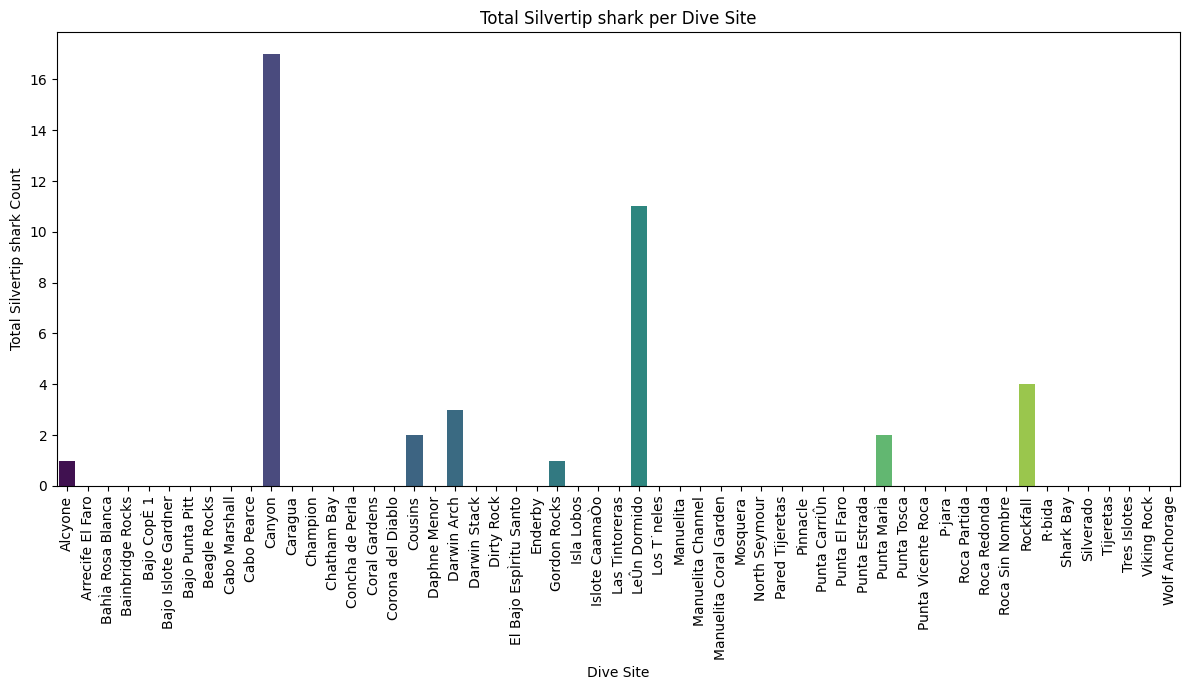

/tmp/ipykernel_5991/2203117226.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='diveSite', y=col, data=animal_per_site, palette='viridis')


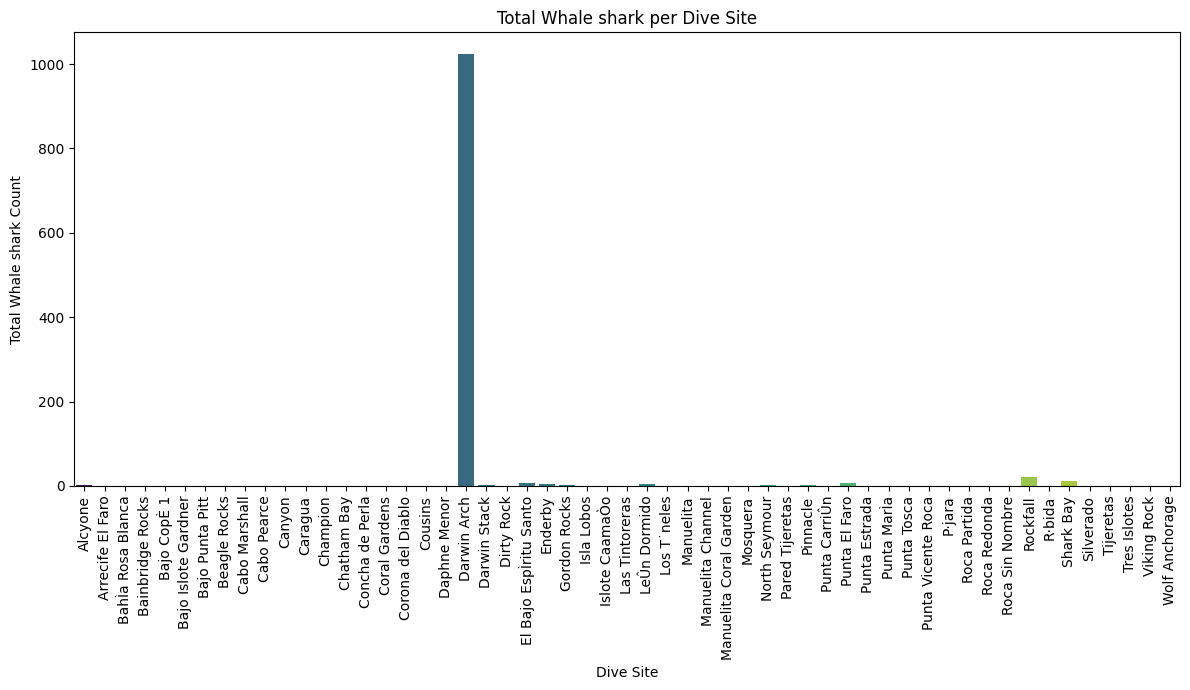

/tmp/ipykernel_5991/2203117226.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='diveSite', y=col, data=animal_per_site, palette='viridis')


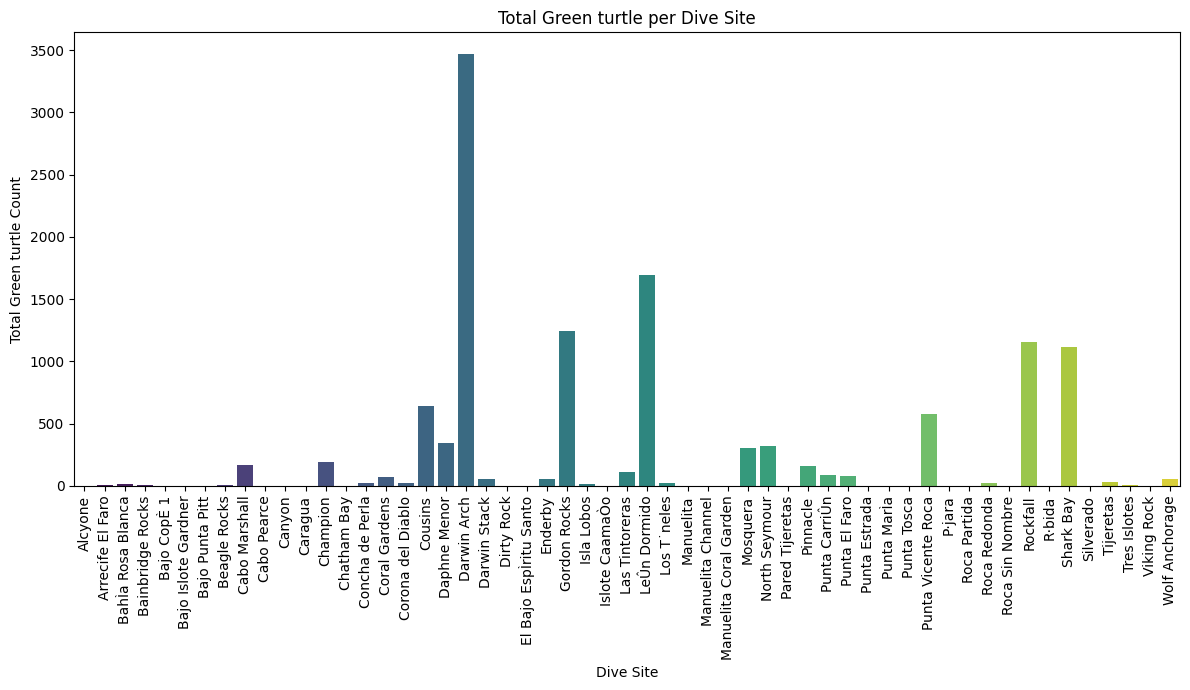

/tmp/ipykernel_5991/2203117226.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='diveSite', y=col, data=animal_per_site, palette='viridis')


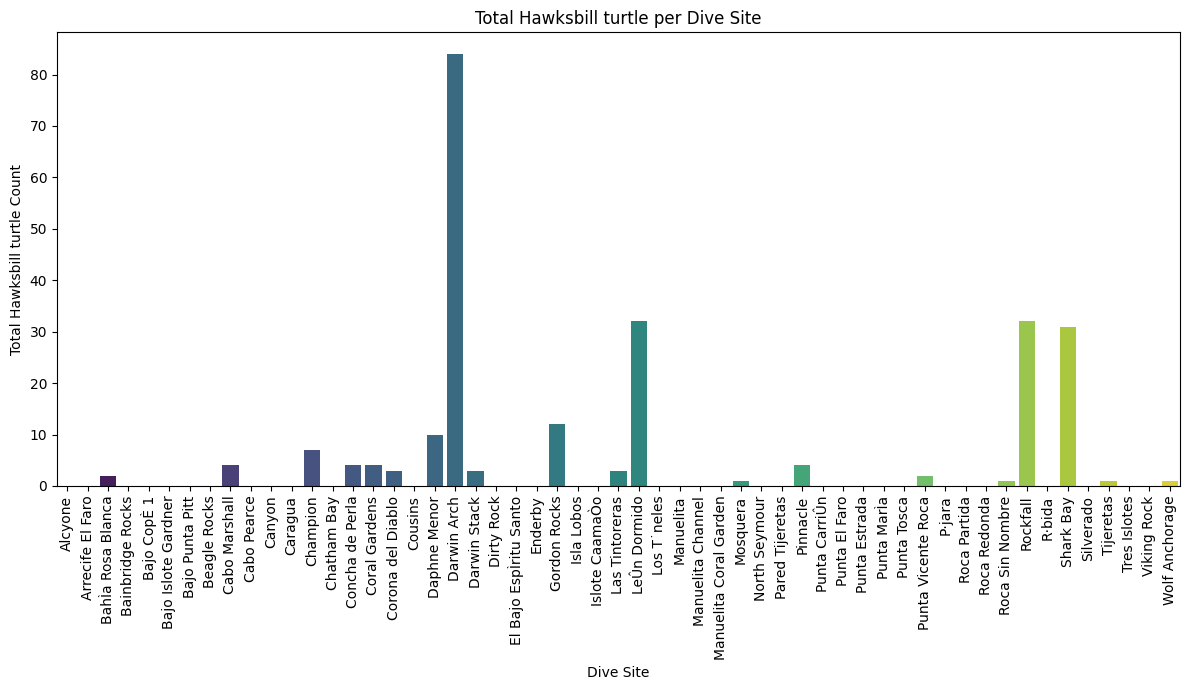

/tmp/ipykernel_5991/2203117226.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='diveSite', y=col, data=animal_per_site, palette='viridis')


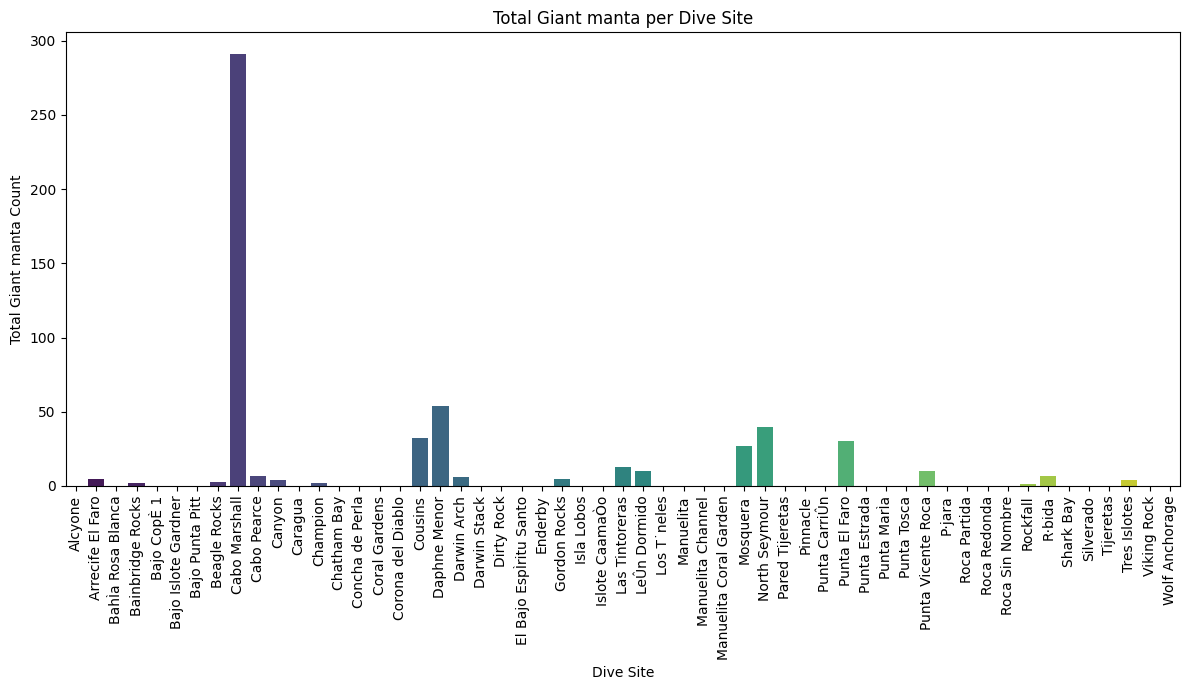

/tmp/ipykernel_5991/2203117226.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='diveSite', y=col, data=animal_per_site, palette='viridis')


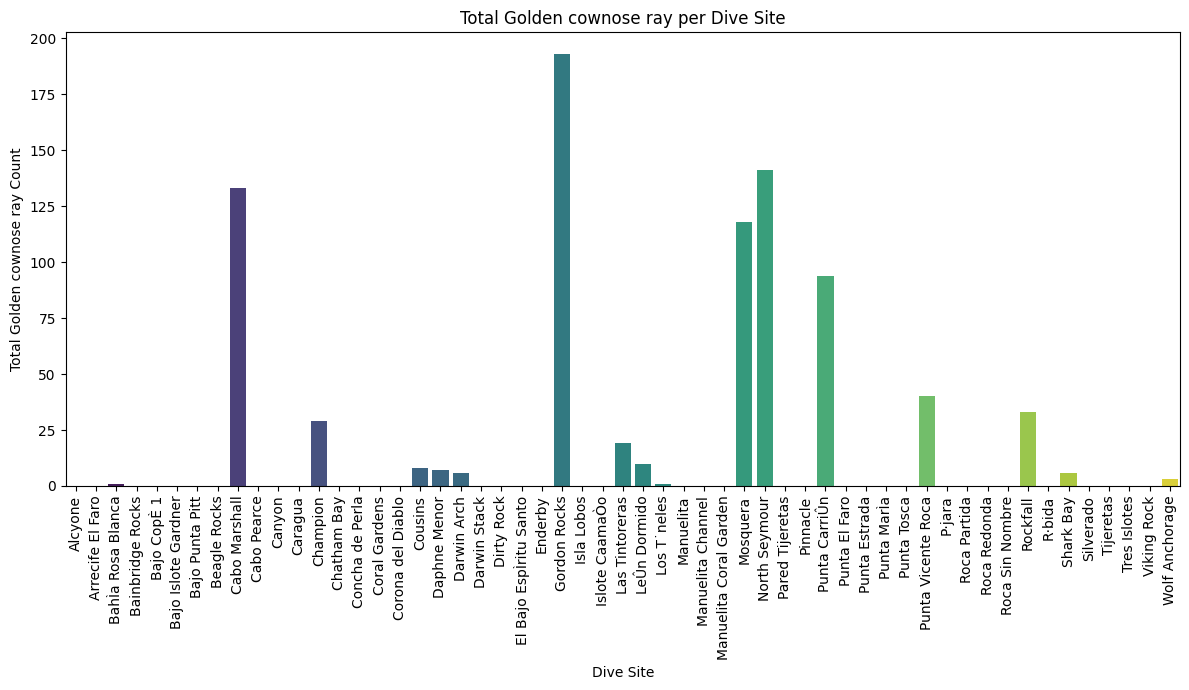

/tmp/ipykernel_5991/2203117226.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='diveSite', y=col, data=animal_per_site, palette='viridis')


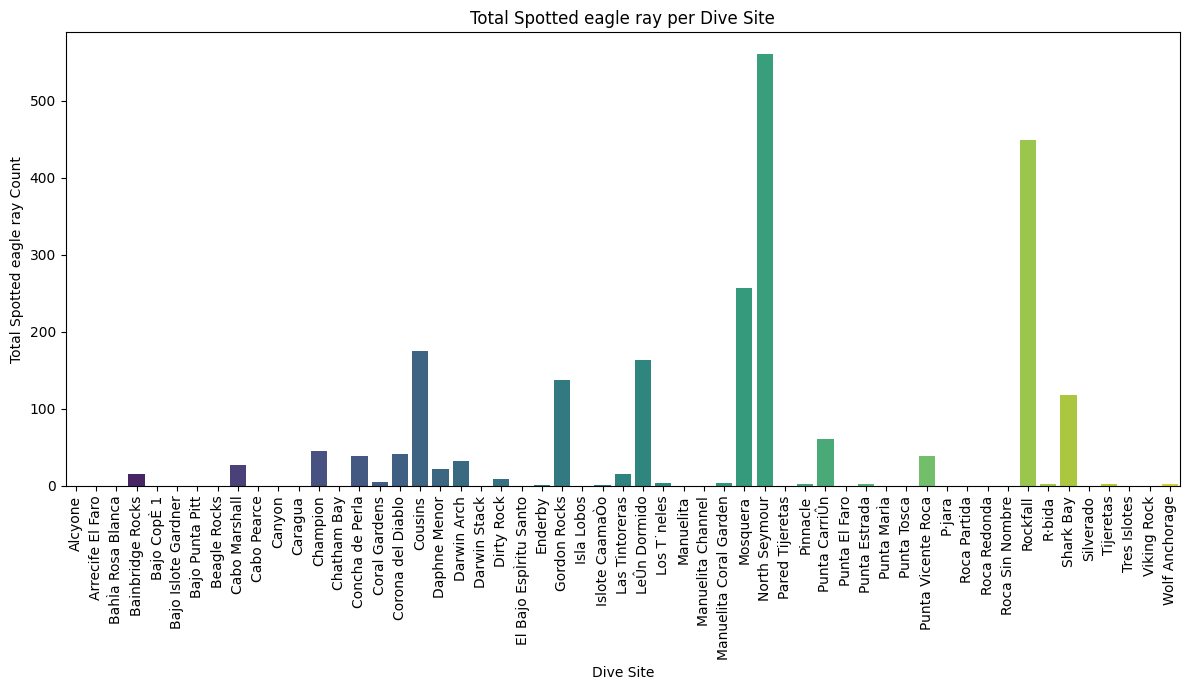

/tmp/ipykernel_5991/2203117226.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='diveSite', y=col, data=animal_per_site, palette='viridis')


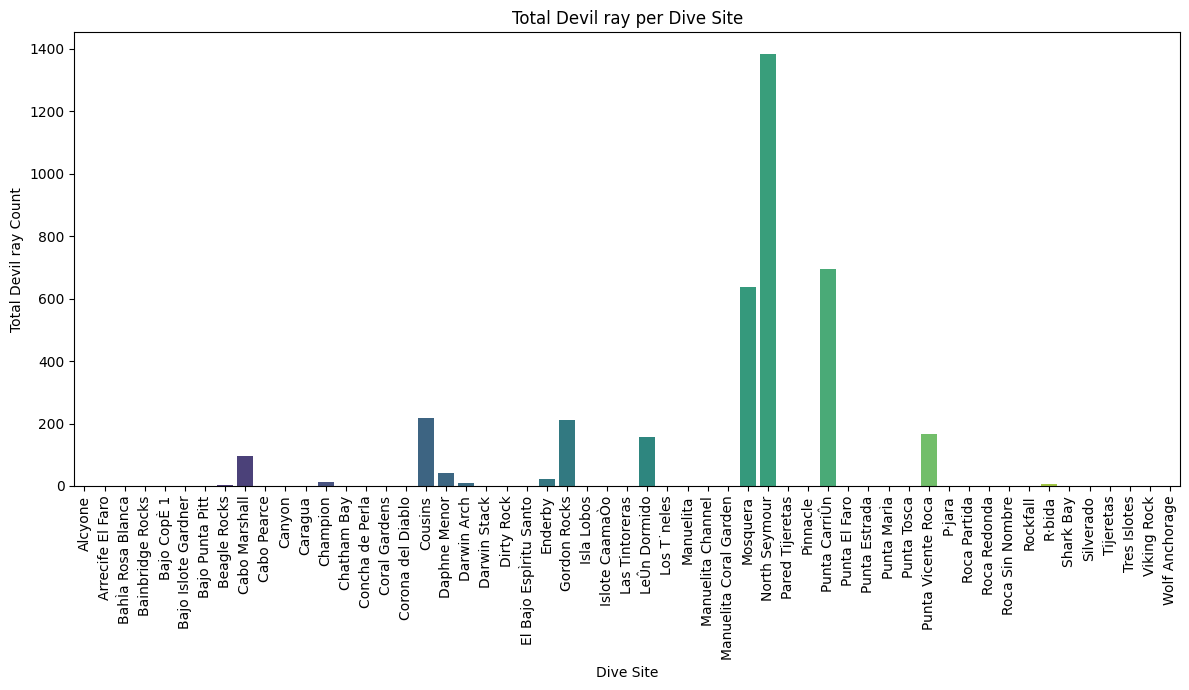

/tmp/ipykernel_5991/2203117226.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='diveSite', y=col, data=animal_per_site, palette='viridis')


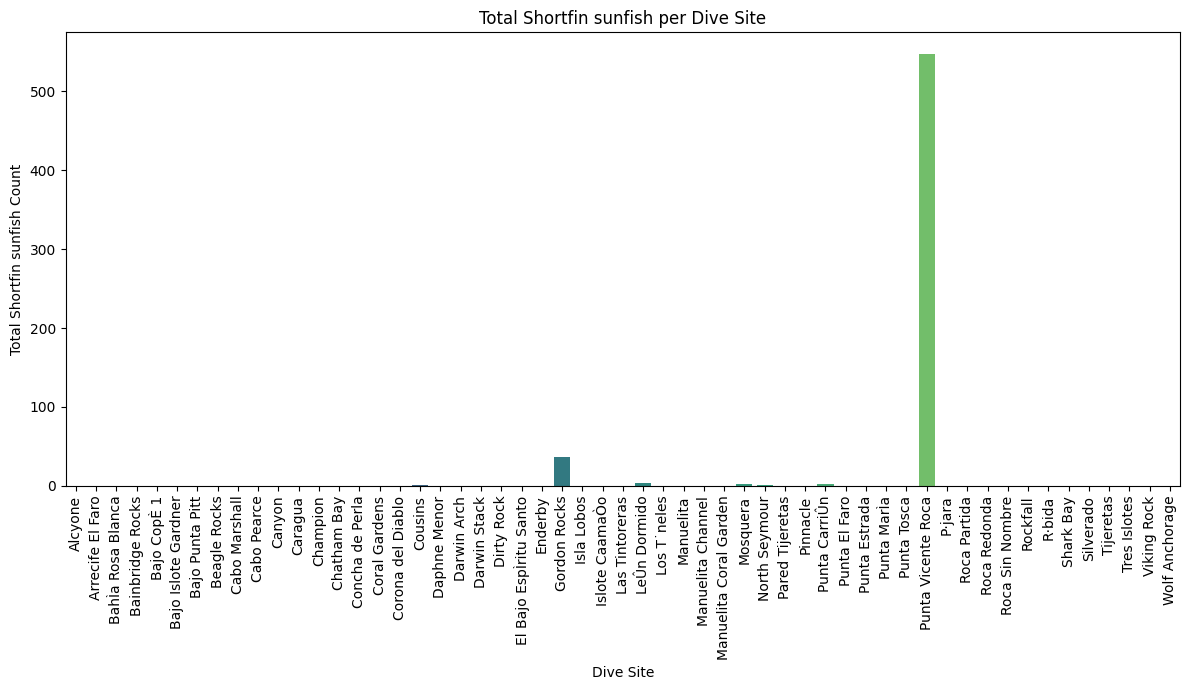

In [11]:
# Placeholder for sun fish count column. User needs to verify/change this.
animal_cols = data_cleaned.columns[11:]

for col in animal_cols:
  # Group by diveSite and sum the sun fish count
  animal_per_site = data_cleaned.groupby('diveSite')[col].sum().reset_index()

  # Sort for better visualization (optional)
  #animal_per_site = animal_per_site.sort_values(by=col, ascending=False)

  plt.figure(figsize=(12, 7))
  sns.barplot(x='diveSite', y=col, data=animal_per_site, palette='viridis')
  plt.title(f'Total {col} per Dive Site')
  plt.xlabel('Dive Site')
  plt.ylabel(f'Total {col} Count')
  plt.xticks(rotation=90) # Rotate site names for better readability
  plt.tight_layout() # Adjust layout to prevent labels from being cut off
  plt.show()


In [ ]:
ray_cols = ['Giant manta', 'Golden cownose ray', 'Spotted eagle ray', 'Devil ray']
print(ray_cols)

['Giant manta', 'Golden cownose ray', 'Spotted eagle ray', 'Devil ray']


/tmp/ipykernel_2277/1315268909.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




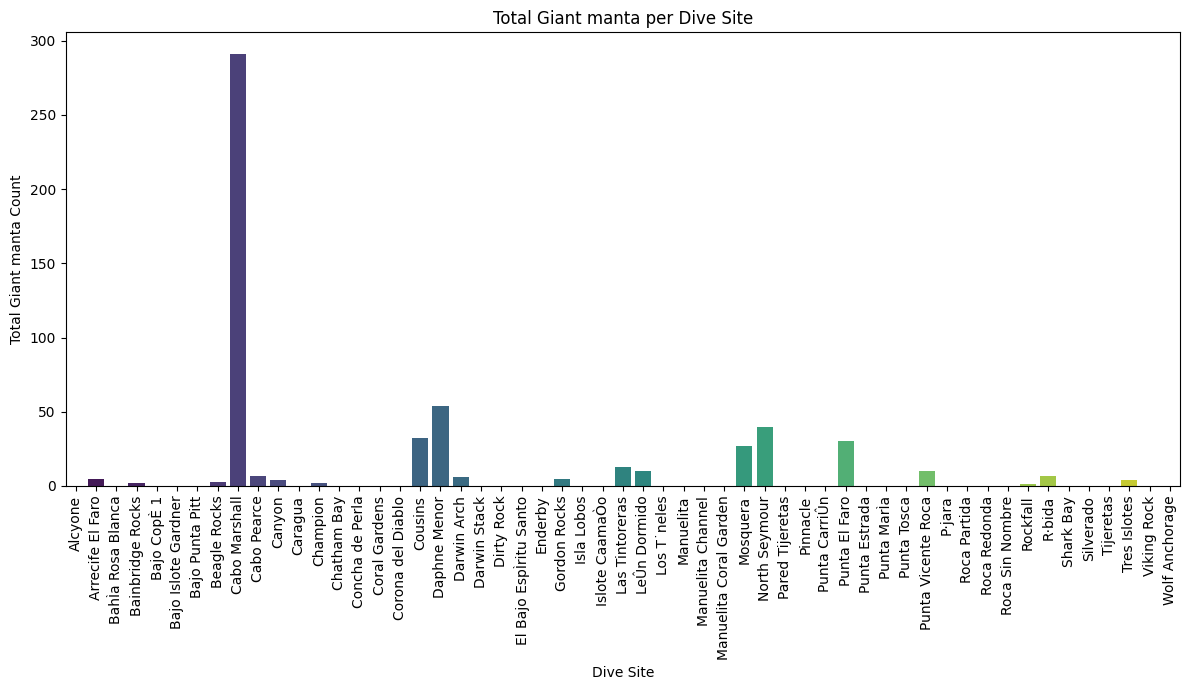

/tmp/ipykernel_2277/1315268909.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




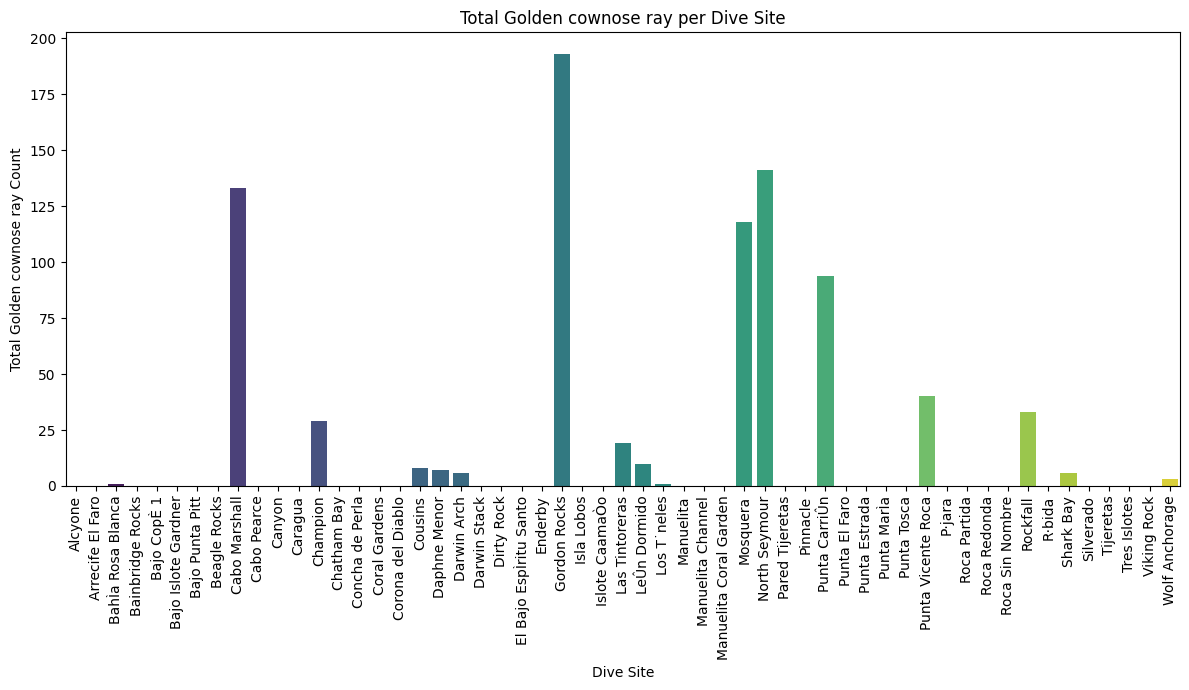

/tmp/ipykernel_2277/1315268909.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




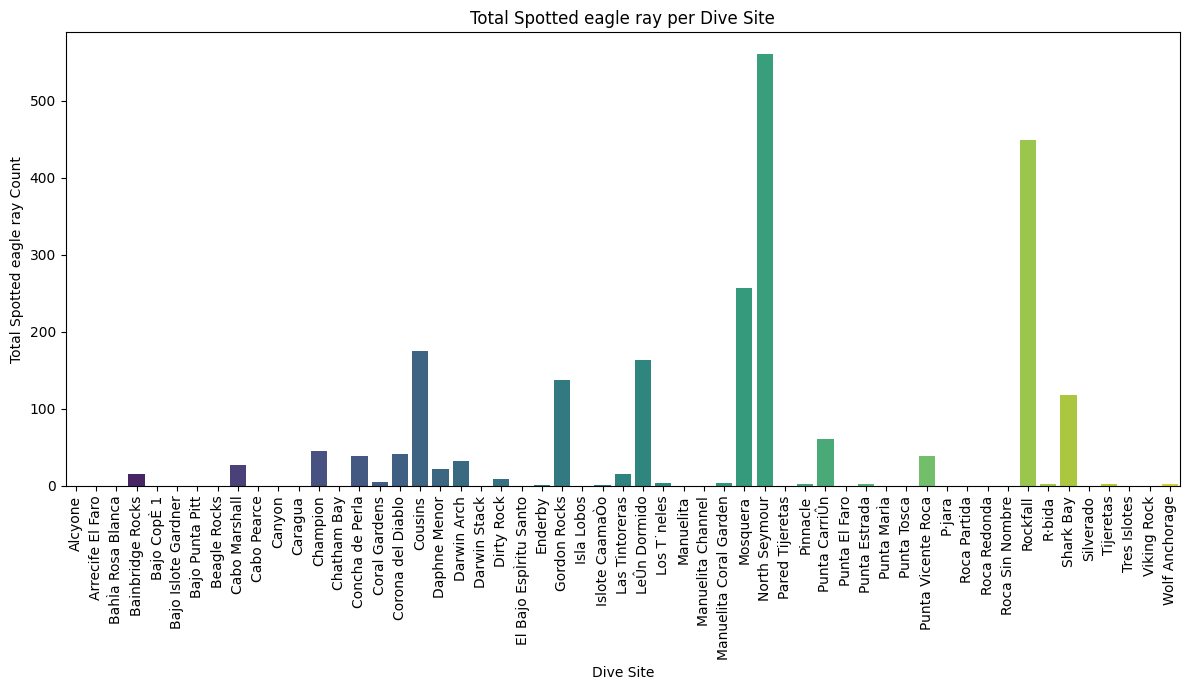

/tmp/ipykernel_2277/1315268909.py:9: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




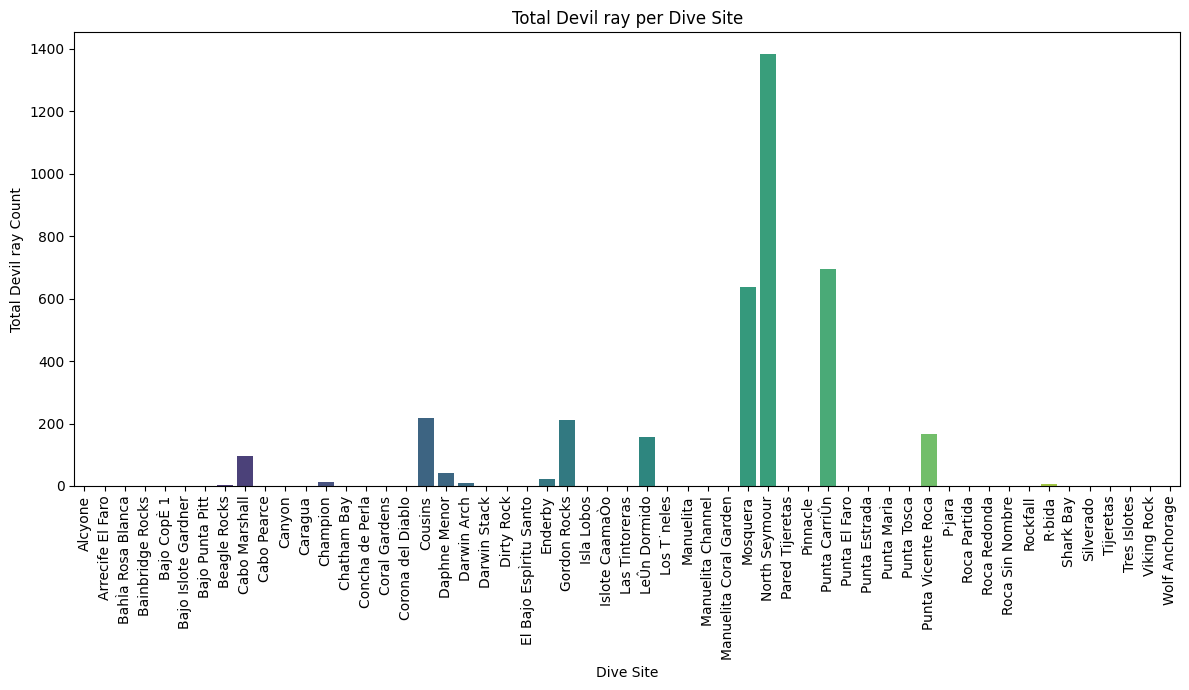

In [ ]:
for col in ray_cols:
  # Group by diveSite and sum the sun fish count
  animal_per_site = data_cleaned.groupby('diveSite')[col].sum().reset_index()

  # Sort for better visualization (optional)
  #animal_per_site = animal_per_site.sort_values(by=col, ascending=False)

  plt.figure(figsize=(12, 7))
  sns.barplot(x='diveSite', y=col, data=animal_per_site, palette='viridis')
  plt.title(f'Total {col} per Dive Site')
  plt.xlabel('Dive Site')
  plt.ylabel(f'Total {col} Count')
  plt.xticks(rotation=90) # Rotate site names for better readability
  plt.tight_layout() # Adjust layout to prevent labels from being cut off
  plt.show()

In [51]:
# Convert 'date' column to datetime objects for temporal analysis
data_cleaned['date'] = pd.to_datetime(data_cleaned['date'])
print("Date column converted to datetime.")

Date column converted to datetime.


In [62]:
data_cleaned = data_cleaned[data_cleaned['date'].dt.year == 2025]
print("Data filtered to include only records from 2025.")
display(data_cleaned.head())

Data filtered to include only records from 2025.


,reportType,region,island,diveSite,uid,date,isHistoric,Hammerhead shark,Galapagos shark,Galapagos bullhead shark,...,Whale shark,Green turtle,Hawksbill turtle,Giant manta,Golden cownose ray,Spotted eagle ray,Devil ray,Shortfin sunfish,latitude,longitude
0,Scuba dive,Galapagos Islands,Baltra,Mosquera,Sw1ozlnw9JcHk02mFtbps8Fc8OK2,2025-09-02 16:00:00+00:00,NaN,5.0,8.0,NaN,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.401000,-90.279810
1,Scuba dive,Galapagos Islands,Wolf,Shark Bay,2uyOIFEMpkOKDLp9YIWgdGrw0WA2,2025-08-29 21:30:00+00:00,NaN,30.0,2.0,NaN,...,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2,Scuba dive,Galapagos Islands,Wolf,Rockfall,2uyOIFEMpkOKDLp9YIWgdGrw0WA2,2025-08-29 19:30:00+00:00,NaN,15.0,34.0,NaN,...,0.0,8.0,0.0,0.0,0.0,7.0,0.0,0.0,1.389538,-91.821166
3,Scuba dive,Galapagos Islands,Wolf,Rockfall,2uyOIFEMpkOKDLp9YIWgdGrw0WA2,2025-08-29 16:30:00+00:00,NaN,11.0,38.0,NaN,...,0.0,6.0,0.0,0.0,0.0,5.0,0.0,0.0,1.389538,-91.821166
4,Scuba dive,Galapagos Islands,Wolf,Shark Bay,2uyOIFEMpkOKDLp9YIWgdGrw0WA2,2025-08-29 13:30:00+00:00,NaN,24.0,5.0,NaN,...,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN


In [ ]:
# Identify the top dive site for 'Giant manta'
manta_per_site = data_cleaned.groupby('diveSite')['Giant manta'].sum().reset_index()
top_manta_site = manta_per_site.sort_values(by='Giant manta', ascending=False).iloc[0]
top_site_name = top_manta_site['diveSite']
top_site_count = top_manta_site['Giant manta']

print(f"The top dive site for Giant Manta is '{top_site_name}' with a total count of {top_site_count}.")

The top dive site for Giant Manta is 'Cabo Marshall' with a total count of 291.0.


### Temporal Trends of Giant Manta at the Top Site

/tmp/ipykernel_2277/695371202.py:20: UserWarning:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.



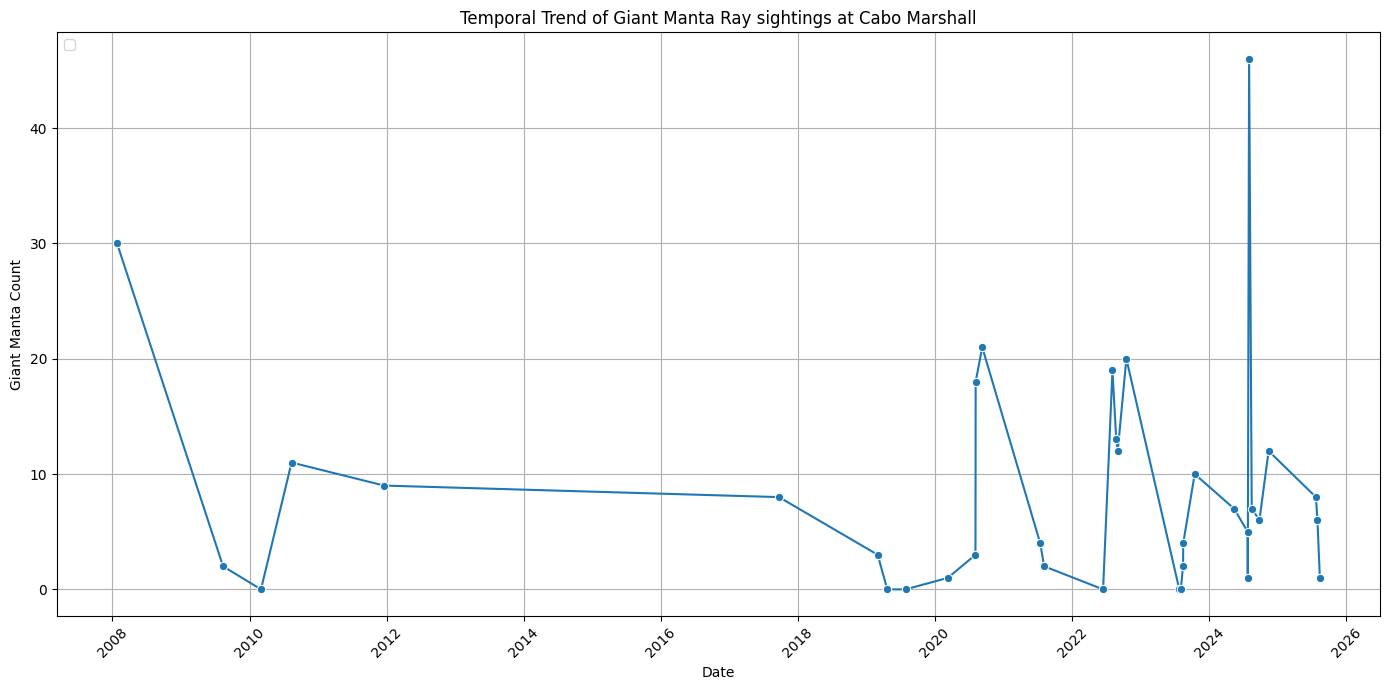

In [ ]:
# Filter data for the top site
top_site_data = data_cleaned[data_cleaned['diveSite'] == top_site_name]

# Group by date and sum 'Giant manta' counts
manta_temporal_trend = top_site_data.groupby(top_site_data['date'].dt.date)['Giant manta'].sum().reset_index()

# Convert date column to datetime objects for plotting
manta_temporal_trend['date'] = pd.to_datetime(manta_temporal_trend['date'])

# Plot the temporal trend
plt.figure(figsize=(14, 7))
ax = sns.lineplot(x='date', y='Giant manta', data=manta_temporal_trend, marker='o')


plt.title(f'Temporal Trend of Giant Manta Ray sightings at {top_site_name}')
plt.xlabel('Date')
plt.ylabel('Giant Manta Count')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

In [25]:
manta_sites = data_cleaned[data_cleaned['Giant manta'] > 0]['diveSite'].unique()
print(manta_sites)

['Cabo Marshall' 'Punta Vicente Roca' 'North Seymour' 'Las Tintoreras'
 'Darwin Arch' 'Mosquera' 'LeÛn Dormido' 'R·bida' 'Daphne Menor'
 'Champion' 'Bainbridge Rocks' 'Cousins' 'Gordon Rocks' 'Beagle Rocks'
 'Rockfall']


### Manually Enter Dive Site Coordinates

In [26]:
import pandas as pd

# Manually define the dive site coordinates
# Replace the example data with your actual dive sites, latitudes, and longitudes.
coords_data = {
    'diveSite': ['Cabo Marshall', 'Punta Vicente Roca', 'North Seymour',
                 'Las Tintoreras', 'Darwin Arch', 'Mosquera',
 'LeÛn Dormido', 'R·bida', 'Daphne Menor', 'Champion',
 'Bainbridge Rocks', 'Cousins', 'Gordon Rocks', 'Beagle Rocks', 'Rockfall'],
    'latitude': [-0.025237, -0.053744, -0.31860, -0.968467, 1.671851, -0.40100, -0.77745, -0.423568, -0.39688, -1.238940, -0.349649, -0.37216, -0.56677, -0.417253, 1.389538],
    'longitude': [-91.198599, -91.560880, -90.25818, -90.959924, -91.990693, -90.27981, -89.51931, -90.704894, -90.35088, -90.385660, -90.564508, -90.56717, -90.1423, -90.6308189, -91.821166]
}
coords_df = pd.DataFrame(coords_data)

print("Manually entered dive site coordinates:")
display(coords_df.head())

# Merge the manually entered coordinates with the main data_cleaned DataFrame
data_cleaned = pd.merge(data_cleaned, coords_df, on='diveSite', how='left')

print("Data with latitude and longitude added:")
display(data_cleaned.head())

Manually entered dive site coordinates:


,diveSite,latitude,longitude
0,Cabo Marshall,-0.025237,-91.198599
1,Punta Vicente Roca,-0.053744,-91.560880
2,North Seymour,-0.318600,-90.258180
3,Las Tintoreras,-0.968467,-90.959924
4,Darwin Arch,1.671851,-91.990693


Data with latitude and longitude added:


,reportType,region,island,diveSite,uid,date,isHistoric,Hammerhead shark,Galapagos shark,Galapagos bullhead shark,...,Whale shark,Green turtle,Hawksbill turtle,Giant manta,Golden cownose ray,Spotted eagle ray,Devil ray,Shortfin sunfish,latitude,longitude
0,Scuba dive,Galapagos Islands,Baltra,Mosquera,Sw1ozlnw9JcHk02mFtbps8Fc8OK2,2025-09-02T16:00:00.000Z,NaN,5.0,8.0,NaN,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,-0.401000,-90.279810
1,Scuba dive,Galapagos Islands,Wolf,Shark Bay,2uyOIFEMpkOKDLp9YIWgdGrw0WA2,2025-08-29T21:30:00.000Z,NaN,30.0,2.0,NaN,...,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN
2,Scuba dive,Galapagos Islands,Wolf,Rockfall,2uyOIFEMpkOKDLp9YIWgdGrw0WA2,2025-08-29T19:30:00.000Z,NaN,15.0,34.0,NaN,...,0.0,8.0,0.0,0.0,0.0,7.0,0.0,0.0,1.389538,-91.821166
3,Scuba dive,Galapagos Islands,Wolf,Rockfall,2uyOIFEMpkOKDLp9YIWgdGrw0WA2,2025-08-29T16:30:00.000Z,NaN,11.0,38.0,NaN,...,0.0,6.0,0.0,0.0,0.0,5.0,0.0,0.0,1.389538,-91.821166
4,Scuba dive,Galapagos Islands,Wolf,Shark Bay,2uyOIFEMpkOKDLp9YIWgdGrw0WA2,2025-08-29T13:30:00.000Z,NaN,24.0,5.0,NaN,...,0.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN


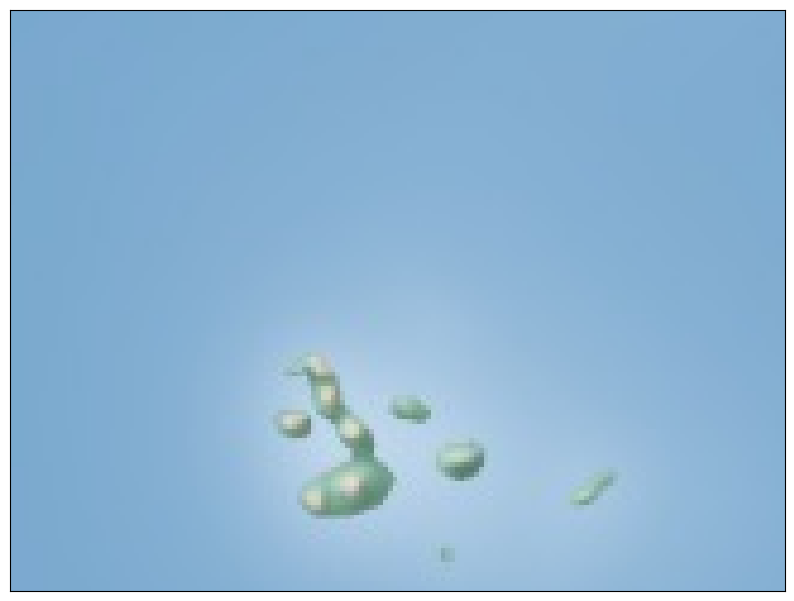

In [46]:
# import Basemap library
from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt

# setup Lambert Conformal basemap.
# set resolution=None to skip processing of boundary datasets.
plt.figure(figsize=(10, 8)) # Make the output image larger
m = Basemap(width=600000,height=450000,projection='lcc',
            resolution='h',lat_1=0.1,lat_2=0.9,lat_0=0.5,lon_0=-90.8)
m.shadedrelief()
plt.show()

In [13]:
# Define the list of animal species columns
animal_species_cols = data_cleaned.columns[7:data_cleaned.columns.get_loc('Shortfin sunfish') + 1]

# List of dive sites to analyze
dive_sites_of_interest = ['Gordon Rocks', 'Darwin Arch']

for site in dive_sites_of_interest:
    # Filter data for the current dive site
    site_data = data_cleaned[data_cleaned['diveSite'] == site]

    # Sum the counts for each species at this site
    species_counts = site_data[animal_species_cols].sum()

    # Count how many species have a total count greater than 0
    num_different_species = (species_counts > 0).sum()

    print(f"Number of different species found at '{site}': {num_different_species}")

Number of different species found at 'Gordon Rocks': 13
Number of different species found at 'Darwin Arch': 14


### Abundance of Species at Gordon Rocks and Darwin Arch

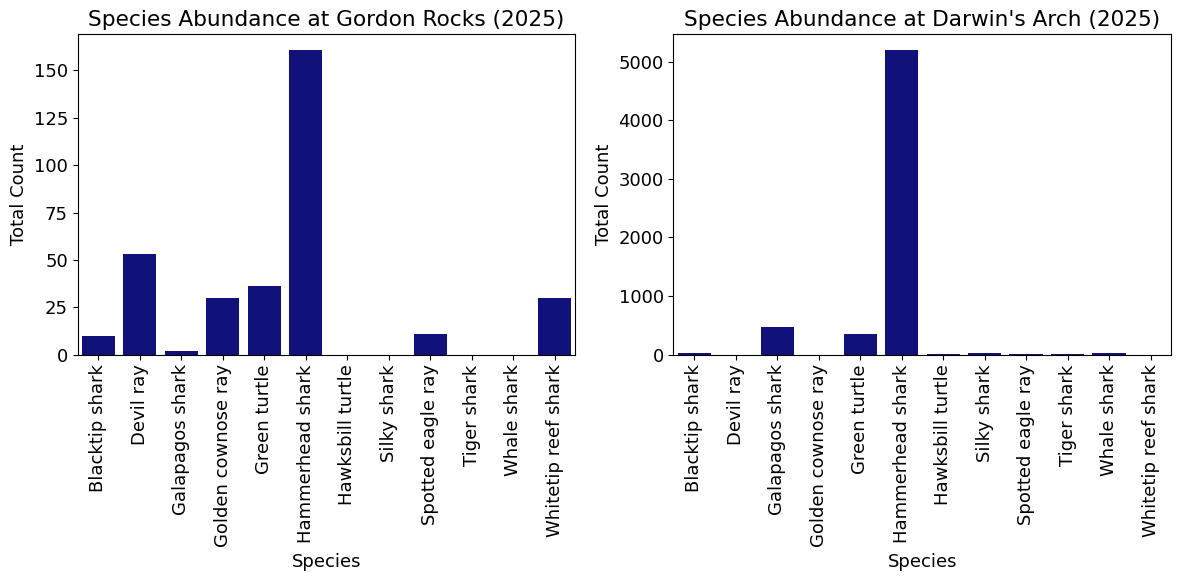

In [101]:
import matplotlib.pyplot as plt
import seaborn as sns

data_cleaned = data_cleaned[data_cleaned['date'].dt.year == 2025]

# Define the list of animal species columns
animal_species_cols = data_cleaned.columns[7:data_cleaned.columns.get_loc('Shortfin sunfish') + 1]

# Filter data for 'Gordon Rocks' and 'Darwin Arch'
dive_sites_of_interest_data = data_cleaned[data_cleaned['diveSite'].isin(['Gordon Rocks', 'Darwin Arch'])]

# Group by diveSite and sum the counts for each species
species_abundance_by_site = dive_sites_of_interest_data.groupby('diveSite')[animal_species_cols].sum()

# Identify all unique species present across both sites with non-zero counts
# This will ensure both plots have the same species on the x-axis
all_present_species = species_abundance_by_site.columns[(species_abundance_by_site != 0).any(axis=0)].tolist()

# Sort the species alphabetically for consistent ordering
all_present_species.sort()

# Set a smaller figure size and adjust font sizes for better readability
plt.rcParams.update({'font.size': 13}) # Increase general font size
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=False) # Smaller figure size

# Plot for Darwin Arch
darwin_arch_data = species_abundance_by_site.loc[['Darwin Arch'], all_present_species].T.reset_index()
darwin_arch_data.columns = ['Species', 'Count']
sns.barplot(x='Species', y='Count', data=darwin_arch_data, color='darkblue', ax=axes[1], order=all_present_species, legend=False)
axes[1].set_title("Species Abundance at Darwin's Arch (2025)")
axes[1].set_xlabel('Species')
axes[1].set_ylabel('Total Count')
axes[1].tick_params(axis='x', rotation=90)

# Plot for Gordon Rocks
gordon_rocks_data = species_abundance_by_site.loc[['Gordon Rocks'], all_present_species].T.reset_index()
gordon_rocks_data.columns = ['Species', 'Count']
sns.barplot(x='Species', y='Count', data=gordon_rocks_data, ax=axes[0], order=all_present_species, legend=False, color='darkblue')
axes[0].set_title('Species Abundance at Gordon Rocks (2025)')
axes[0].set_xlabel('Species')
axes[0].set_ylabel('Total Count')
axes[0].tick_params(axis='x', rotation=90)



plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

/tmp/ipykernel_5991/958228249.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='diveSite', y='total_sightings_per_dive', data=dive_sites_of_interest_data, palette=['skyblue', 'skyblue'])


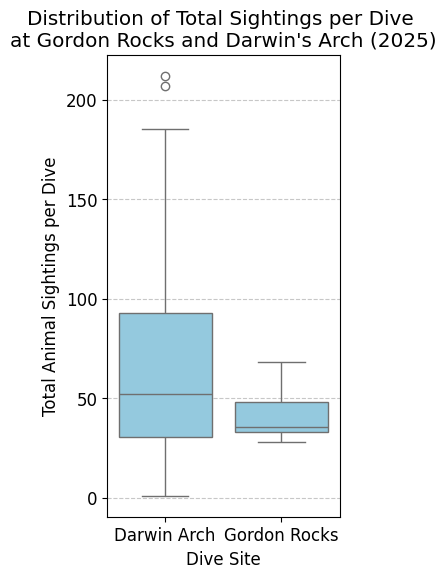

In [102]:
# Define the list of animal species columns (same as used in previous cells)
animal_species_cols = data_cleaned.columns[7:data_cleaned.columns.get_loc('Shortfin sunfish') + 1]

# Filter data for 'Gordon Rocks' and 'Darwin Arch' and make a copy to avoid SettingWithCopyWarning
dive_sites_of_interest_data = data_cleaned[data_cleaned['diveSite'].isin(['Gordon Rocks', 'Darwin Arch'])].copy()

# Calculate total sightings per dive by summing across all animal species columns for each row
dive_sites_of_interest_data['total_sightings_per_dive'] = dive_sites_of_interest_data[animal_species_cols].sum(axis=1)
plt.rcParams.update({'font.size': 12}) # Increase general font size

# Create a box plot to visualize the distribution of total sightings per dive
plt.figure(figsize=(3, 6))
# Changed palette to use distinct color names instead of colormap names in a list
sns.boxplot(x='diveSite', y='total_sightings_per_dive', data=dive_sites_of_interest_data, palette=['skyblue', 'skyblue'])
plt.title("Distribution of Total Sightings per Dive \nat Gordon Rocks and Darwin's Arch (2025)")
plt.xlabel('Dive Site')
plt.ylabel('Total Animal Sightings per Dive')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

plt.rcParams.update({'font.size': 12}) # Increase general font size

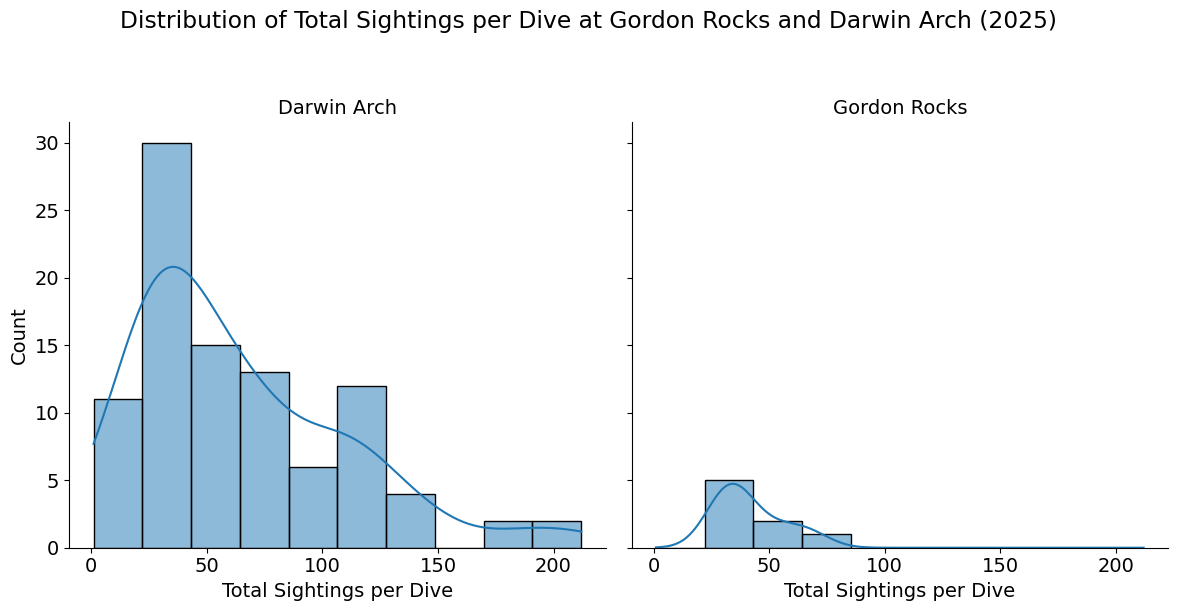

In [78]:
# Create histograms for 'total_sightings_per_dive' for both dive sites
# sns.displot is a figure-level function that creates its own figure and FacetGrid
g = sns.displot(data=dive_sites_of_interest_data, x='total_sightings_per_dive', col='diveSite', kde=True, height=6, aspect=1)
g.fig.suptitle('Distribution of Total Sightings per Dive at Gordon Rocks and Darwin Arch (2025)', y=1.02)
g.set_axis_labels('Total Sightings per Dive', 'Count')
g.set_titles(col_template="{col_name}")
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()

In [100]:
from scipy.stats import mannwhitneyu

# Define the list of animal species columns (same as used in previous cells)
animal_species_cols = data_cleaned.columns[7:data_cleaned.columns.get_loc('Shortfin sunfish') + 1]

# Filter data for 'Gordon Rocks' and 'Darwin Arch' and make a copy to avoid SettingWithCopyWarning
dive_sites_of_interest_data = data_cleaned[data_cleaned['diveSite'].isin(['Gordon Rocks', 'Darwin Arch'])].copy()

# Calculate total sightings per dive by summing across all animal species columns for each row
dive_sites_of_interest_data['total_sightings_per_dive'] = dive_sites_of_interest_data[animal_species_cols].sum(axis=1)

# Extract total sightings per dive for each site
gordon_rocks_sightings = dive_sites_of_interest_data[dive_sites_of_interest_data['diveSite'] == 'Gordon Rocks']['total_sightings_per_dive']
darwin_arch_sightings = dive_sites_of_interest_data[dive_sites_of_interest_data['diveSite'] == 'Darwin Arch']['total_sightings_per_dive']

# Perform Mann-Whitney U test
stat, p_value = mannwhitneyu(gordon_rocks_sightings, darwin_arch_sightings, alternative='two-sided')

print(f"Mann-Whitney U Statistic: {stat}")
print(f"P-value: {p_value}")

# Interpret the results
alpha = 0.05 # Significance level
if p_value < alpha:
    print("\nBased on the Mann-Whitney U test, there is a statistically significant difference in total animal sightings per dive between Gordon Rocks and Darwin Arch.")
else:
    print("\nBased on the Mann-Whitney U test, there is no statistically significant difference in total animal sightings per dive between Gordon Rocks and Darwin Arch.")

Mann-Whitney U Statistic: 295.0
P-value: 0.2977052933590538

Based on the Mann-Whitney U test, there is no statistically significant difference in total animal sightings per dive between Gordon Rocks and Darwin Arch.


/tmp/ipykernel_5991/2506065685.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='upper left')


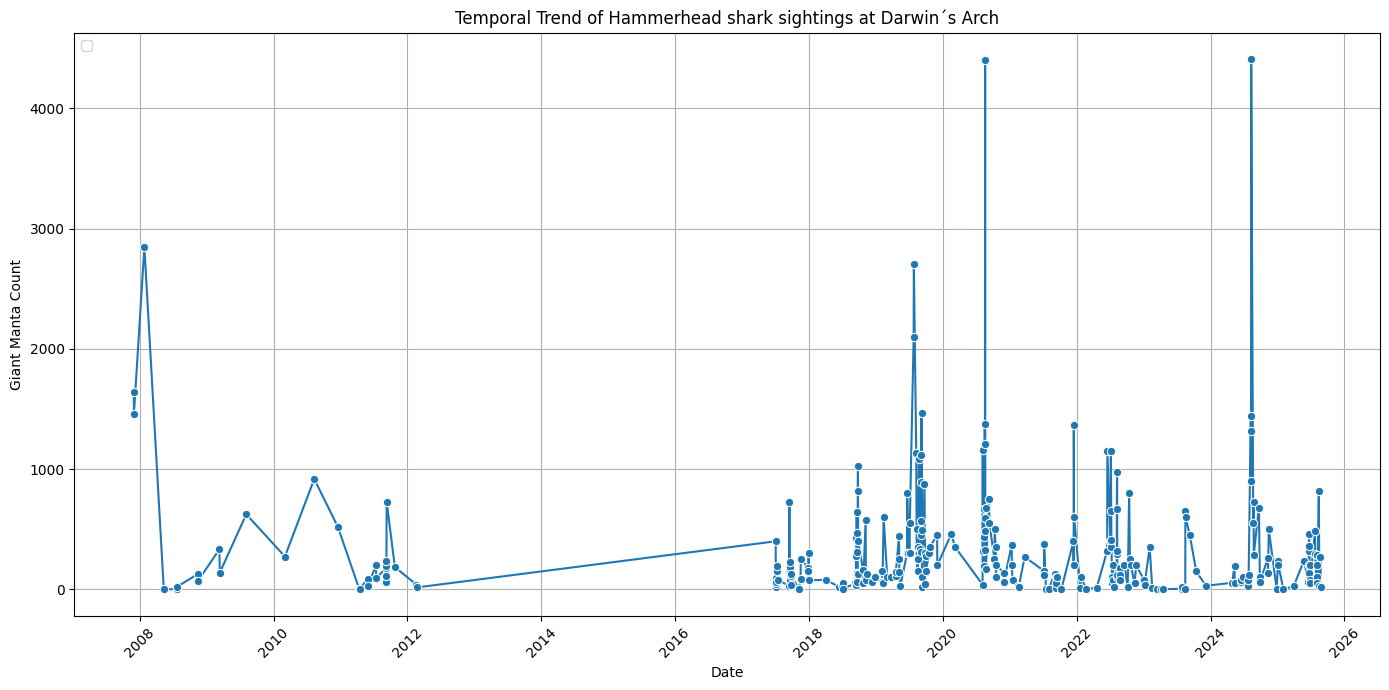

In [54]:
# Filter data for the top site
top_site_data = data_cleaned[data_cleaned['diveSite'] == 'Darwin Arch']

# Group by date and sum 'Giant manta' counts
manta_temporal_trend = top_site_data.groupby(top_site_data['date'].dt.date)['Hammerhead shark'].sum().reset_index()

# Convert date column to datetime objects for plotting
manta_temporal_trend['date'] = pd.to_datetime(manta_temporal_trend['date'])

# Plot the temporal trend
plt.figure(figsize=(14, 7))
ax = sns.lineplot(x='date', y='Hammerhead shark', data=manta_temporal_trend, marker='o')


plt.title(f'Temporal Trend of Hammerhead shark sightings at Darwin´s Arch')
plt.xlabel('Date')
plt.ylabel('Giant Manta Count')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

/tmp/ipykernel_5991/1127292453.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  species_abundance_top_5['Total'] = species_abundance_top_5.sum(axis=1)


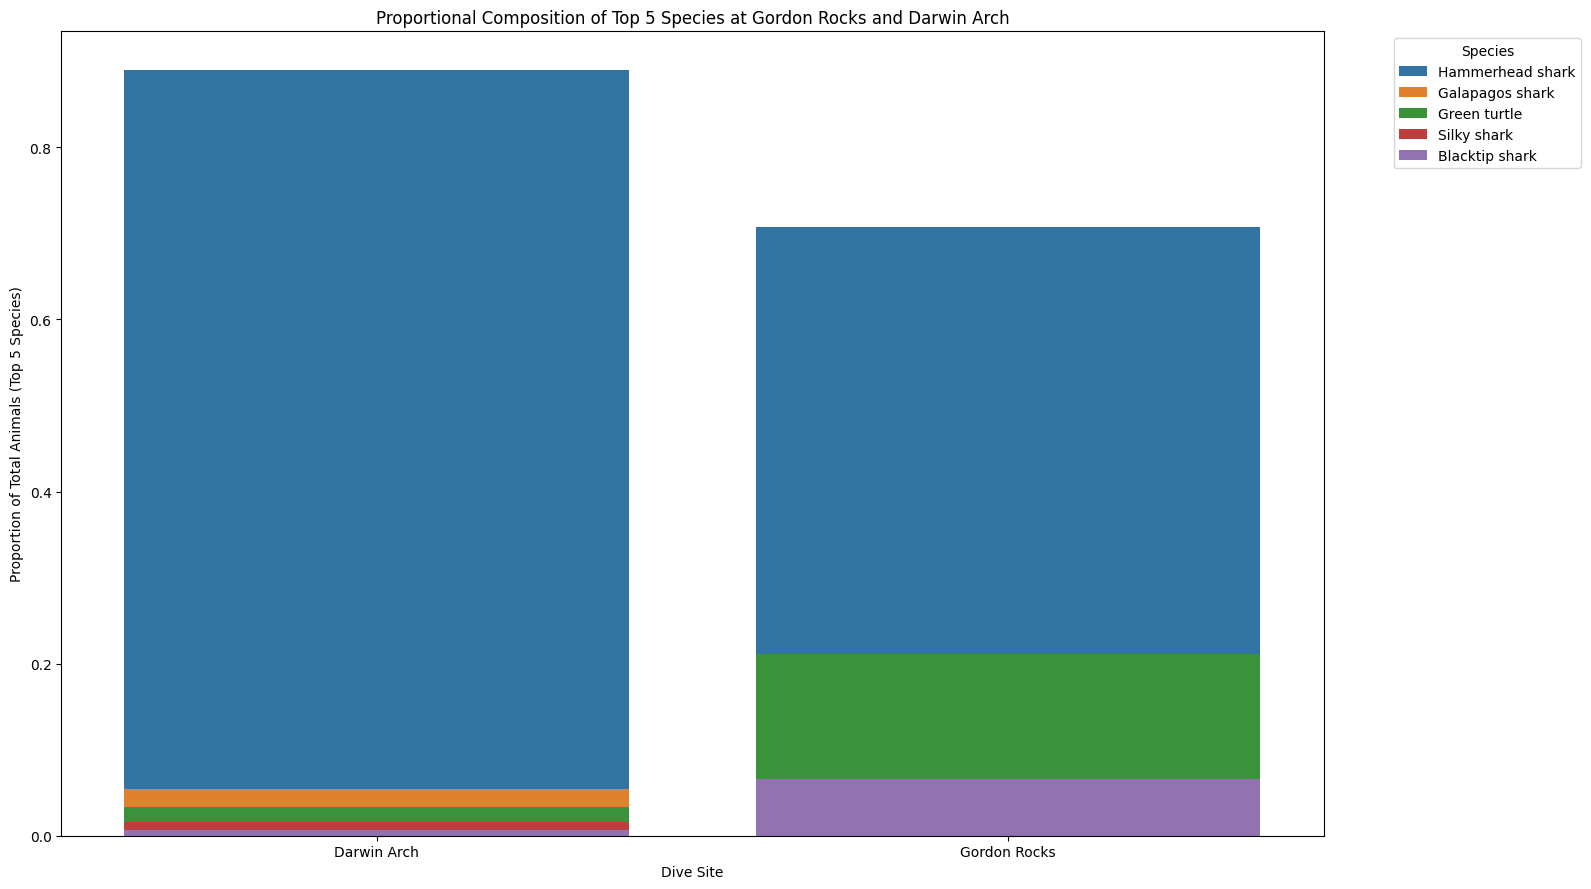

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the list of all animal species columns
animal_species_cols = data_cleaned.columns[7:data_cleaned.columns.get_loc('Shortfin sunfish') + 1]

# Filter data for 'Gordon Rocks' and 'Darwin Arch'
dive_sites_of_interest_data = data_cleaned[data_cleaned['diveSite'].isin(['Gordon Rocks', 'Darwin Arch'])]

# Group by diveSite and sum the counts for each species
species_abundance_by_site = dive_sites_of_interest_data.groupby('diveSite')[animal_species_cols].sum()

# Calculate total counts across both sites to determine overall top species
total_species_counts = species_abundance_by_site.sum(axis=0)

# Get the top 5 species based on total counts across both sites
top_5_species = total_species_counts.nlargest(5).index.tolist()

# Filter species_abundance_by_site to include only the top 5 species
species_abundance_top_5 = species_abundance_by_site[top_5_species]

# Calculate the total count for each site based on top 5 species to get proportions
species_abundance_top_5['Total'] = species_abundance_top_5.sum(axis=1)

# Calculate proportions for the top 5 species
species_proportions_top_5 = species_abundance_top_5.div(species_abundance_top_5['Total'], axis=0)

# Drop the 'Total' column from proportions
species_proportions_top_5 = species_proportions_top_5.drop(columns='Total')

# Melt the DataFrame for easier plotting with seaborn
species_proportions_melted_top_5 = species_proportions_top_5.reset_index().melt(id_vars=['diveSite'],
                                                                                 var_name='Species',
                                                                                 value_name='Proportion')

plt.figure(figsize=(16, 9))
sns.barplot(x='diveSite', y='Proportion', hue='Species', data=species_proportions_melted_top_5, dodge=False)
plt.title('Proportional Composition of Top 5 Species at Gordon Rocks and Darwin Arch')
plt.xlabel('Dive Site')
plt.ylabel('Proportion of Total Animals (Top 5 Species)')
plt.xticks(rotation=0)
plt.legend(title='Species', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()